# Distortion

This notebook gives a rough estimate of the distortion in the latent space using `compute_distortion` from `ixplore.metrics`.

- Sample synthetic users on a grid spanning the model's limits.
- Re-embed them from their predicted responses.
- Map the per-location displacement and report mean and standard deviation.
- Repeat under sparsified responses.

In [1]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ixplore import IXPLORE
from ixplore.metrics import compute_distortion
from ixplore.visualization import clean_axis

logging.getLogger('ixplore').setLevel(logging.WARNING)

## Load a pretrained model

We reuse the embedding and item parameters from `demo.ipynb` so the latent space is fixed throughout the notebook.

In [2]:
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)

xplore = IXPLORE(reactions,
                 pretrained_embedding=embedding,
                 pretrained_models=models)

## Round-trip on a grid

`compute_distortion` builds a `resolution × resolution` grid over `model.limits`, predicts answers at each point, re-embeds, and returns the original positions, the re-embedded positions, and the displacement mean and std.

In [3]:
grid, reembedded, mean, std = compute_distortion(xplore, resolution=25)
print(f'mean displacement: {mean:.3f}')
print(f'std displacement:  {std:.3f}')

mean displacement: 0.047
std displacement:  0.053


## Original vs re-embedded positions

Each candidate is coloured by its grid coordinates (red = x, blue = y). The right panel draws a line from the original to the re-embedded position.

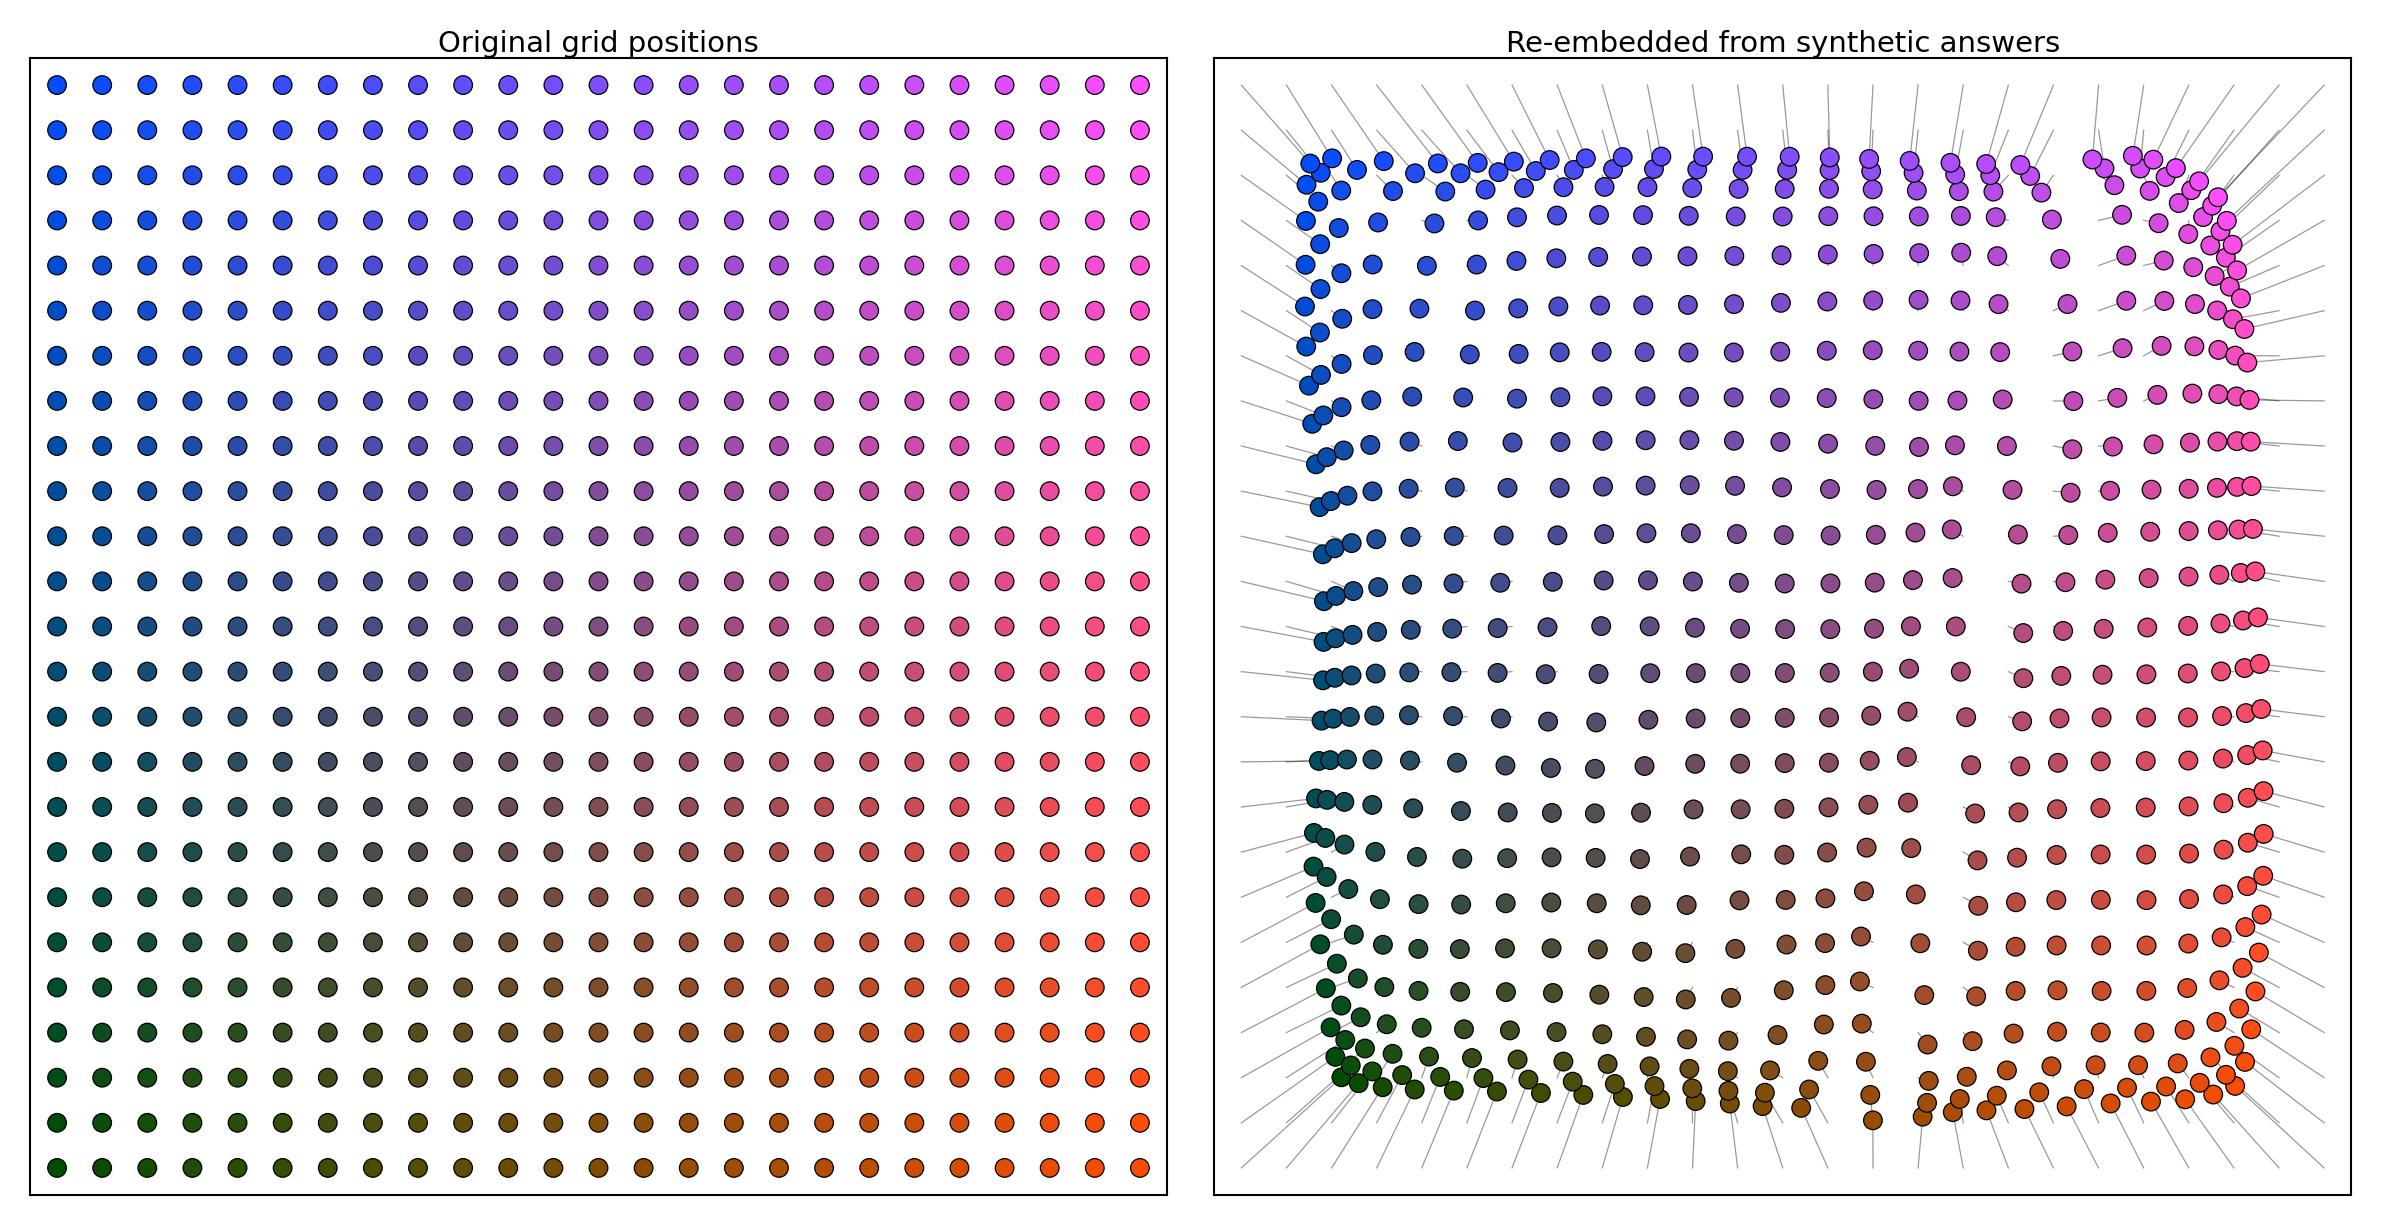

In [4]:
low, high = xplore.limits
cx = (grid[:, 0] - low) / (high - low)
cy = (grid[:, 1] - low) / (high - low)
colors = np.column_stack([cx, 0.3 * np.ones(len(grid)), cy])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.scatter(grid[:, 0], grid[:, 1], c=colors, s=20, edgecolors='k', lw=0.3)
clean_axis(ax1, limits=(low - 0.05, high + 0.05))
ax1.set_title('Original grid positions')

for i in range(len(grid)):
    ax2.plot([grid[i, 0], reembedded[i, 0]],
             [grid[i, 1], reembedded[i, 1]],
             c='k', lw=0.3, alpha=0.4, zorder=1)
ax2.scatter(reembedded[:, 0], reembedded[:, 1], c=colors, s=20, edgecolors='k', lw=0.3, zorder=2)
clean_axis(ax2, limits=(low - 0.05, high + 0.05))
ax2.set_title('Re-embedded from synthetic answers')

fig.tight_layout()
plt.show()

## Distortion under sparsified responses

We sweep the `keep_fraction` argument (fraction of items kept per synthetic user) and record mean and std of the displacement.

In [6]:
rows = []
for keep_fraction in [1.0, 0.5, 0.25, 0.1]:
    _, _, m, s = compute_distortion(xplore, resolution=25, keep_fraction=keep_fraction)
    rows.append({'keep_fraction': keep_fraction, 'mean': m, 'std': s})

pd.DataFrame(rows).set_index('keep_fraction').round(3)

,mean,std
keep_fraction,,
1.00,0.047,0.053
0.50,0.076,0.076
0.25,0.125,0.111
0.10,0.245,0.184
